# **Analysis of Populist Groups**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Import dataset
ep = pd.read_csv('../data/ep_speeches_classified_total.csv')

In [3]:
ep['party'].unique()

array(['Greens/EFA', 'PPE', 'S&D', 'Renew', 'ID', 'The Left', 'ECR', 'NI',
       '-', 'GUE/NGL', 'ALDE', 'EFDD', 'ENF', 'UEN', 'IND/DEM'],
      dtype=object)

In [8]:
ep['party'] = ep['party'].replace({
    'GUE/NGL': 'The Left',
    'ALDE': 'Renew',
    'ENF': 'ID',
})

In [5]:
# Import dataset on populist ep party groups 
populist_groups = pd.read_excel('../data/ep_populist_party_data.xlsx')
populist_groups.head()

,country,year,party,party_name_short,party_eng,party_year,ep_political_group,vote_share,seats,total_group_seats,total_ep_seats,rightwing,radicalright,leftwing,valence,party_entry,group_change
0,Great Britain,1999,United Kingdom Independence Party,UKIP,United Kingdom Independence Party,UKIP_1999,EDD,7.0,3,18,788,1,0,0,0,1,0
1,Italy,1999,Forza Italia / Il Popolo della Libertà,FI / PdL,Forza Italia – The People of Freedom,FI / PdL_1999,EPP,25.2,22,295,788,1,0,0,0,1,0
2,Germany,1999,Partei des Demokratischen Sozialismus / Die Linke,PDS/LINKE,PDS / The Left,PDS/LINKE_1999,GUE/NGL,5.8,6,55,788,0,0,1,0,1,0
3,Greece,1999,Dimokratiko Koinoniko Kinima,DIKKI,Democratic Social Movement,DIKKI_1999,GUE/NGL,6.9,2,55,788,0,0,1,0,1,0
4,Netherlands,1999,Socialistiese Partij,SP,Socialist Party,SP_1999,GUE/NGL,5.0,1,55,788,0,0,1,0,1,0


In [6]:
populist_groups['ep_political_group'].unique()

array(['EDD', 'EPP', 'GUE/NGL', 'NI', 'UEN', 'ALDE', 'IND/DEM', 'PSE',
       'ECR', 'EFD', 'EFDD', 'ENF', 'ID', 'Renew', 'The Left'],
      dtype=object)

In [9]:
populist_groups['ep_political_group'] = populist_groups['ep_political_group'].replace({
    'EPP': 'PPE',
    'PSE': 'S&D',
    'GUE/NGL': 'The Left',
    'ALDE': 'Renew',
    'EDD': 'IND/DEM',
    'EFD': 'EFDD',
    'ENF': 'ID',
})

### Metrics on Populist Parties in EP

In [10]:
# Populist parties per legislative period
populist_groups['year'].value_counts().sort_index()

year
1999    10
2004    18
2009    25
2014    25
2019    32
Name: count, dtype: int64

In [12]:
# Share of populist parties per legislative period

# Total populist seats per period
populist_seats = populist_groups.groupby('year')['seats'].sum().reset_index(name='populist_seats')

# Total EP seats per period (assuming total_ep_seats is constant per period, take the first/max value)
total_seats = populist_groups.groupby('year')['total_ep_seats'].first().reset_index()

# Merge and calculate share
seats_share = pd.merge(populist_seats, total_seats, on='year')
seats_share['populist_share'] = (seats_share['populist_seats'] / seats_share['total_ep_seats']) * 100

print(seats_share)

   year  populist_seats  total_ep_seats  populist_share
0  1999              51             788        6.472081
1  2004              94             785       11.974522
2  2009             131             764       17.146597
3  2014             174             749       23.230975
4  2019             225             703       32.005690


In [14]:
# Share of populist national parties within the EP political groups

# Total populist seats per group per period
populist_seats_group = populist_groups.groupby(['year', 'ep_political_group'])['seats'].sum().reset_index(name='populist_seats')

# Total seats per group per period
total_group_seats = populist_groups.groupby(['year', 'ep_political_group'])['total_group_seats'].first().reset_index()

# Merge and calculate share
seats_share_group = pd.merge(populist_seats_group, total_group_seats, on=['year', 'ep_political_group'])
seats_share_group['populist_share_of_group'] = (seats_share_group['populist_seats'] / seats_share_group['total_group_seats']) * 100

seats_share_group.head(20)

,year,ep_political_group,populist_seats,total_group_seats,populist_share_of_group
0,1999,IND/DEM,3,18,16.666667
1,1999,NI,16,44,36.363636
2,1999,PPE,22,295,7.457627
3,1999,The Left,9,55,16.363636
4,1999,UEN,1,30,3.333333
5,2004,IND/DEM,23,22,104.545455
6,2004,NI,13,30,43.333333
7,2004,PPE,14,288,4.861111
8,2004,Renew,5,67,7.462687
9,2004,S&D,3,218,1.376147


In [15]:
mean_share_per_group = seats_share_group.groupby('ep_political_group')['populist_share_of_group'].mean().reset_index()
print(mean_share_per_group)

  ep_political_group  populist_share_of_group
0                ECR                75.967587
1               EFDD                99.577573
2                 ID                52.097506
3            IND/DEM                60.606061
4                 NI                75.262626
5                PPE                10.502313
6              Renew                 5.958173
7                S&D                 1.376147
8           The Left                33.465480
9                UEN                33.484848


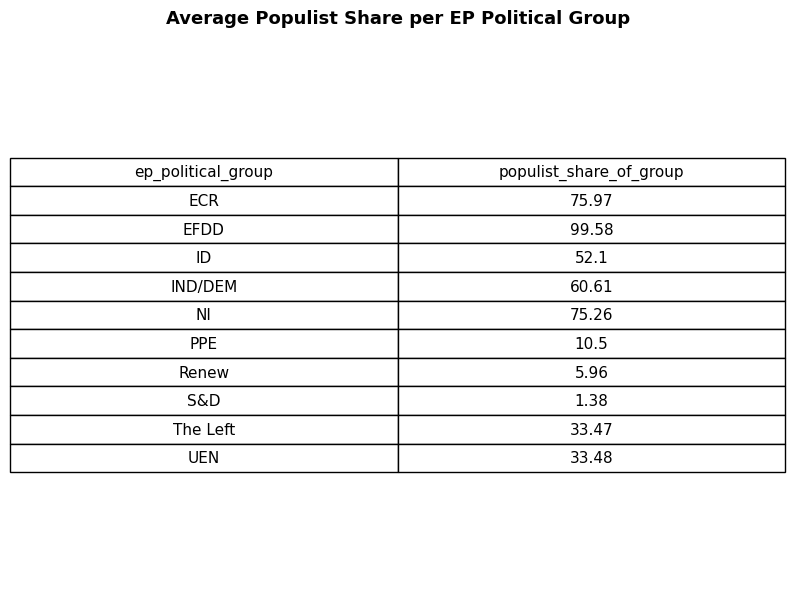

In [20]:
mean_share_per_group = mean_share_per_group.round(2)

fig, ax = plt.subplots(figsize=(8, len(mean_share_per_group) * 0.5 + 1))
ax.axis('off')
table = ax.table(
    cellText=mean_share_per_group.values,
    colLabels=mean_share_per_group.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title('Average Populist Share per EP Political Group', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/tables/mean_populist_share_per_group.png', dpi=150, bbox_inches='tight')
plt.show()

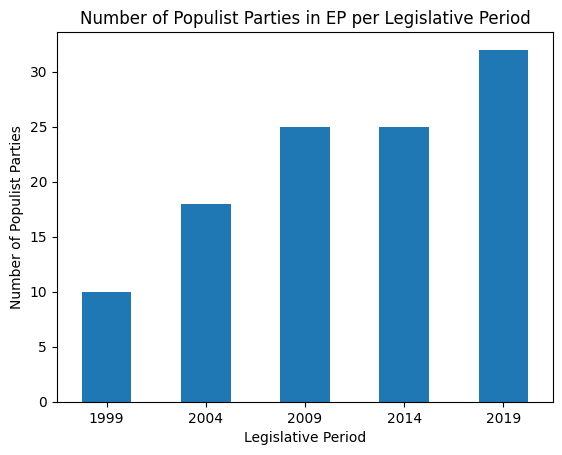

In [18]:
populist_groups['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Populist Parties in EP per Legislative Period')
plt.xlabel('Legislative Period')
plt.ylabel('Number of Populist Parties')
plt.xticks(rotation=0)
plt.show()



In [43]:
# Populism per group 
counts = populist_groups.groupby('ep_political_group')['valence'].value_counts().reset_index()
print(counts)

   ep_political_group  valence  count
0                 ECR        0     18
1                 ECR        1      1
2                EFDD        0      9
3                EFDD        1      1
4                  ID        0     10
5             IND/DEM        0      4
6                  NI        0     20
7                  NI        1      4
8                 PPE        0     11
9                 PPE        1      4
10              Renew        1      5
11                S&D        0      1
12           The Left        0     16
13                UEN        0      6


In [19]:
# Populist parties per EP party group 
populist_groups['ep_political_group'].value_counts()

ep_political_group
NI          24
ECR         19
The Left    16
PPE         15
ID          10
EFDD        10
UEN          6
Renew        5
IND/DEM      4
S&D          1
Name: count, dtype: int64

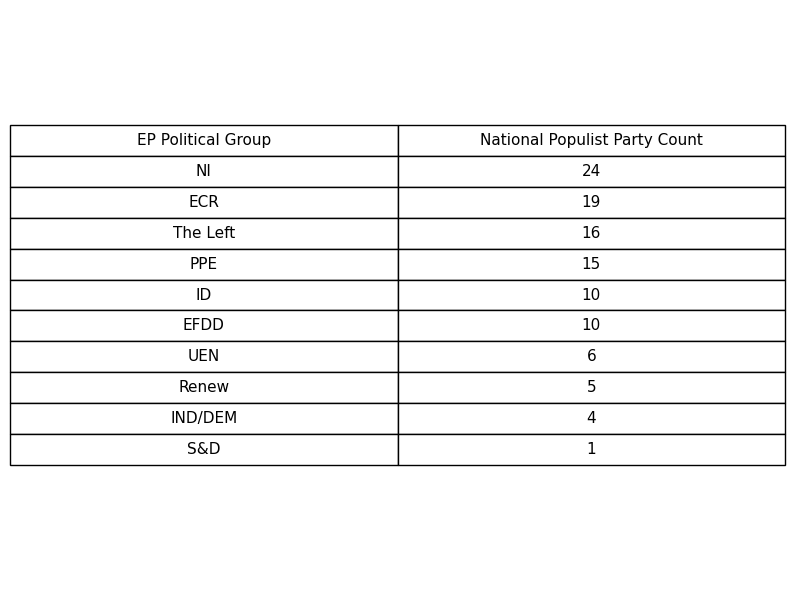

In [39]:
counts = populist_groups['ep_political_group'].value_counts().reset_index()
counts.columns = ['EP Political Group', 'National Populist Party Count']

fig, ax = plt.subplots(figsize=(8, len(counts) * 0.5 + 1))
ax.axis('off')
table = ax.table(cellText=counts.values,
                 colLabels=counts.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

#plt.title('Populist Parties per EP Political Group', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/tables/populist_parties_per_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Calculate
members_per_year = populist_groups.groupby(['year', 'ep_political_group'])['party'].nunique().reset_index(name='members')
print(members_per_year)

    year ep_political_group  members
0   1999            IND/DEM        1
1   1999                 NI        4
2   1999                PPE        1
3   1999           The Left        3
4   1999                UEN        1
5   2004            IND/DEM        3
6   2004                 NI        4
7   2004                PPE        2
8   2004              Renew        1
9   2004                S&D        1
10  2004           The Left        2
11  2004                UEN        5
12  2009                ECR        3
13  2009               EFDD        7
14  2009                 NI        9
15  2009                PPE        3
16  2009              Renew        1
17  2009           The Left        2
18  2014                ECR        7
19  2014               EFDD        3
20  2014                 ID        4
21  2014                 NI        2
22  2014                PPE        4
23  2014              Renew        1
24  2014           The Left        4
25  2019                ECR        9
2

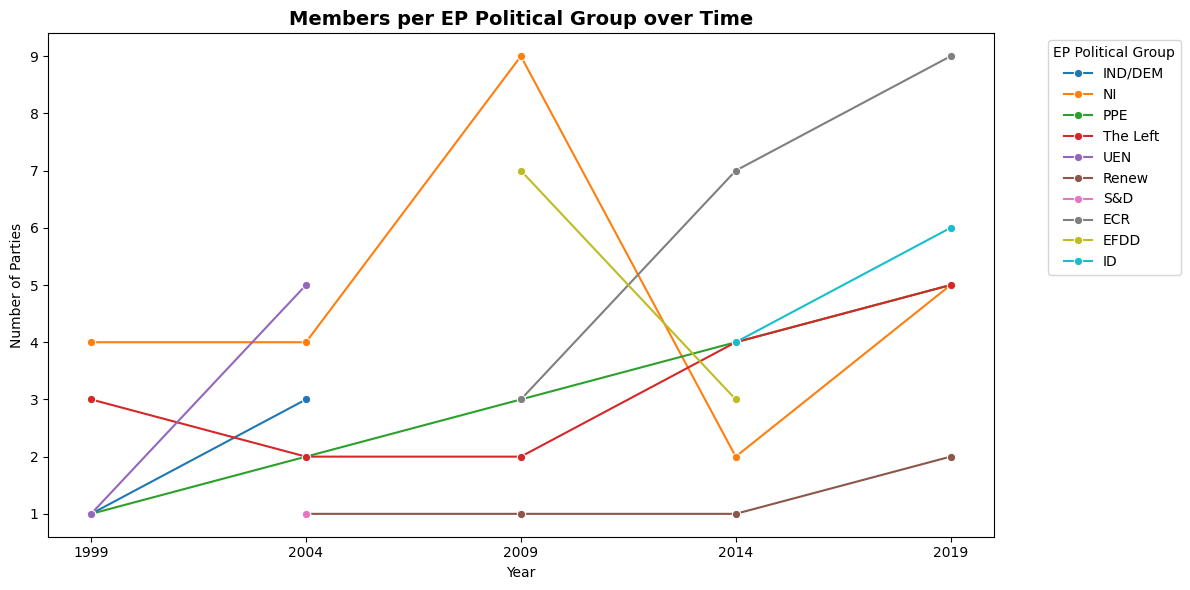

In [ ]:
# Visualise
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=members_per_year,
    x='year',
    y='members',
    hue='ep_political_group',
    marker='o',
)

plt.title('Members per EP Political Group over Time', fontsize=14, fontweight='bold')
plt.ylabel('Number of Parties')
plt.xlabel('Year')
plt.legend(title='EP Political Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('../outputs/graphs/members_per_group_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# Total seats of populist parties per year 
seats_per_group = populist_groups.groupby('year')['seats'].sum().reset_index(name='total_seats')
print(seats_per_group)

   year  total_seats
0  1999           51
1  2004           94
2  2009          131
3  2014          174
4  2019          225


In [40]:
# Number of seats in EP per populist party group over all years
seats_per_group = populist_groups.groupby('ep_political_group')['seats'].sum().reset_index(name='total_seats')
print(seats_per_group)

  ep_political_group  total_seats
0                ECR          151
1               EFDD           73
2                 ID           46
3            IND/DEM           26
4                 NI          136
5                PPE          121
6              Renew           19
7                S&D            3
8           The Left           71
9                UEN           29


In [45]:
# Total seats and number of years present per group
seats_per_group = populist_groups.groupby('ep_political_group').agg(
    total_seats=('seats', 'sum'),
    legislations_present=('year', 'nunique')
).reset_index()

seats_per_group['avg_seats_per_year'] = seats_per_group['total_seats'] / seats_per_group['legislations_present']

print(seats_per_group)

  ep_political_group  total_seats  legislations_present  avg_seats_per_year
0                ECR          151                     3           50.333333
1               EFDD           73                     2           36.500000
2                 ID           46                     2           23.000000
3            IND/DEM           26                     2           13.000000
4                 NI          136                     5           27.200000
5                PPE          121                     5           24.200000
6              Renew           19                     4            4.750000
7                S&D            3                     1            3.000000
8           The Left           71                     5           14.200000
9                UEN           29                     2           14.500000


In [ ]:
# Number of seats in EP per populist party group per year
seats_per_group = populist_groups.groupby(['year', 'ep_political_group'])['seats'].sum().reset_index(name='total_seats')
print(seats_per_group)

    year ep_political_group  total_seats
0   1999            IND/DEM            3
1   1999                 NI           16
2   1999                PPE           22
3   1999           The Left            9
4   1999                UEN            1
5   2004            IND/DEM           23
6   2004                 NI           13
7   2004                PPE           14
8   2004              Renew            5
9   2004                S&D            3
10  2004           The Left            8
11  2004                UEN           28
12  2009                ECR           45
13  2009               EFDD           30
14  2009                 NI           24
15  2009                PPE           21
16  2009              Renew            2
17  2009           The Left            9
18  2014                ECR           31
19  2014               EFDD           43
20  2014                 ID           14
21  2014                 NI           27
22  2014                PPE           34
23  2014        

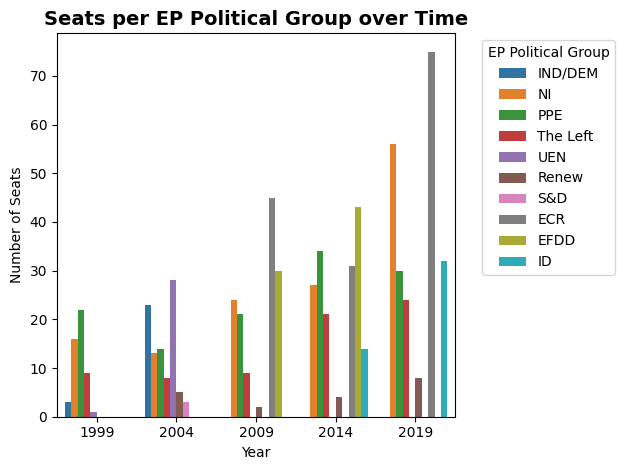

In [32]:
sns.barplot(
    data=seats_per_group,
    x='year',
    y='total_seats',
    hue='ep_political_group',
)

plt.title('Seats per EP Political Group over Time', fontsize=14, fontweight='bold')
plt.ylabel('Number of Seats')
plt.xlabel('Year')
plt.legend(title='EP Political Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('../outputs/graphs/members_per_group_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

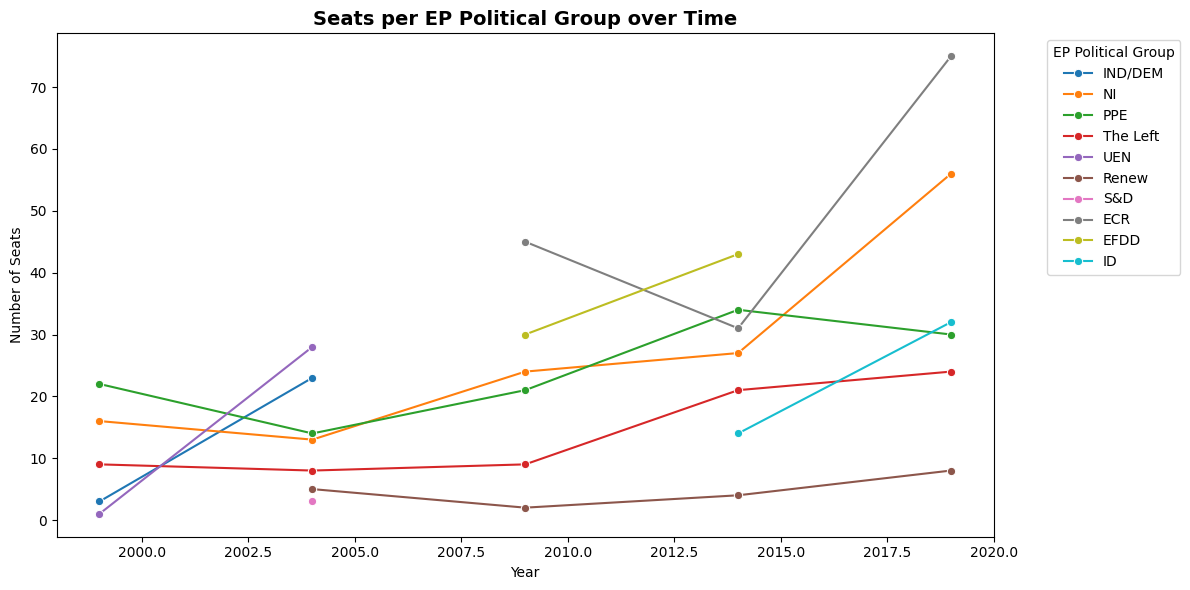

In [30]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=seats_per_group,
    x='year',
    y='total_seats',
    hue='ep_political_group',
    marker='o',
)

plt.title('Seats per EP Political Group over Time', fontsize=14, fontweight='bold')
plt.ylabel('Number of Seats')
plt.xlabel('Year')
plt.legend(title='EP Political Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('../outputs/graphs/members_per_group_over_time.png', dpi=300, bbox_inches='tight')
plt.show()